# Q4: Bayes' Theorem - Engineering vs Arts Students

**Problem Statement:**
In a university:
- 5% of engineering students score above 95% in the final exam
- 2% of arts students score above 95% in the final exam
- 70% of the students are enrolled in arts

**Question:** If a randomly selected student scores above 95%, what is the probability that the student is an arts student?


In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set style
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')
sns.set_palette("husl")


In [2]:
# Given probabilities
P_arts = 0.70  # 70% of students are in arts
P_engineering = 1 - P_arts  # 30% of students are in engineering

P_above95_given_engineering = 0.05  # 5% of engineering students score above 95%
P_above95_given_arts = 0.02  # 2% of arts students score above 95%

print("=" * 60)
print("GIVEN INFORMATION")
print("=" * 60)
print(f"P(Arts) = {P_arts:.2f} ({P_arts*100}%)")
print(f"P(Engineering) = {P_engineering:.2f} ({P_engineering*100}%)")
print(f"\nP(Score > 95% | Engineering) = {P_above95_given_engineering:.2f} ({P_above95_given_engineering*100}%)")
print(f"P(Score > 95% | Arts) = {P_above95_given_arts:.2f} ({P_above95_given_arts*100}%)")
print("=" * 60)


GIVEN INFORMATION
P(Arts) = 0.70 (70.0%)
P(Engineering) = 0.30 (30.000000000000004%)

P(Score > 95% | Engineering) = 0.05 (5.0%)
P(Score > 95% | Arts) = 0.02 (2.0%)


## Solution using Bayes' Theorem

**Formula:** P(Arts | Score > 95%) = P(Score > 95% | Arts) × P(Arts) / P(Score > 95%)

Where P(Score > 95%) = P(Score > 95% | Arts) × P(Arts) + P(Score > 95% | Engineering) × P(Engineering)


In [3]:
# Step 1: Calculate P(Score > 95%) using Law of Total Probability
P_above95 = (P_above95_given_arts * P_arts + 
             P_above95_given_engineering * P_engineering)

print("=" * 60)
print("STEP 1: CALCULATE P(Score > 95%)")
print("=" * 60)
print("Using Law of Total Probability:")
print(f"P(Score > 95%) = P(Score > 95% | Arts) × P(Arts) + P(Score > 95% | Engineering) × P(Engineering)")
print(f"P(Score > 95%) = {P_above95_given_arts:.2f} × {P_arts:.2f} + {P_above95_given_engineering:.2f} × {P_engineering:.2f}")
print(f"P(Score > 95%) = {P_above95_given_arts * P_arts:.4f} + {P_above95_given_engineering * P_engineering:.4f}")
print(f"P(Score > 95%) = {P_above95:.4f} ({P_above95*100:.2f}%)")
print("=" * 60)


STEP 1: CALCULATE P(Score > 95%)
Using Law of Total Probability:
P(Score > 95%) = P(Score > 95% | Arts) × P(Arts) + P(Score > 95% | Engineering) × P(Engineering)
P(Score > 95%) = 0.02 × 0.70 + 0.05 × 0.30
P(Score > 95%) = 0.0140 + 0.0150
P(Score > 95%) = 0.0290 (2.90%)


In [4]:
# Step 2: Calculate P(Arts | Score > 95%) using Bayes' Theorem
P_arts_given_above95 = (P_above95_given_arts * P_arts) / P_above95

print("=" * 60)
print("STEP 2: CALCULATE P(Arts | Score > 95%)")
print("=" * 60)
print("Using Bayes' Theorem:")
print(f"P(Arts | Score > 95%) = P(Score > 95% | Arts) × P(Arts) / P(Score > 95%)")
print(f"P(Arts | Score > 95%) = ({P_above95_given_arts:.2f} × {P_arts:.2f}) / {P_above95:.4f}")
print(f"P(Arts | Score > 95%) = {P_above95_given_arts * P_arts:.4f} / {P_above95:.4f}")
print(f"P(Arts | Score > 95%) = {P_arts_given_above95:.6f}")
print("=" * 60)
print(f"\n✅ FINAL ANSWER: {P_arts_given_above95:.6f} or {P_arts_given_above95*100:.4f}%")
print("=" * 60)


STEP 2: CALCULATE P(Arts | Score > 95%)
Using Bayes' Theorem:
P(Arts | Score > 95%) = P(Score > 95% | Arts) × P(Arts) / P(Score > 95%)
P(Arts | Score > 95%) = (0.02 × 0.70) / 0.0290
P(Arts | Score > 95%) = 0.0140 / 0.0290
P(Arts | Score > 95%) = 0.482759

✅ FINAL ANSWER: 0.482759 or 48.2759%


## Additional Analysis: Calculate P(Engineering | Score > 95%)


In [5]:
# Calculate P(Engineering | Score > 95%) for comparison
P_engineering_given_above95 = (P_above95_given_engineering * P_engineering) / P_above95

print("=" * 60)
print("ADDITIONAL ANALYSIS")
print("=" * 60)
print(f"P(Engineering | Score > 95%) = {P_engineering_given_above95:.6f} ({P_engineering_given_above95*100:.4f}%)")
print(f"P(Arts | Score > 95%) = {P_arts_given_above95:.6f} ({P_arts_given_above95*100:.4f}%)")
print(f"\nVerification: {P_arts_given_above95 + P_engineering_given_above95:.6f} (should be 1.0)")
print("=" * 60)


ADDITIONAL ANALYSIS
P(Engineering | Score > 95%) = 0.517241 (51.7241%)
P(Arts | Score > 95%) = 0.482759 (48.2759%)

Verification: 1.000000 (should be 1.0)


## Visualization


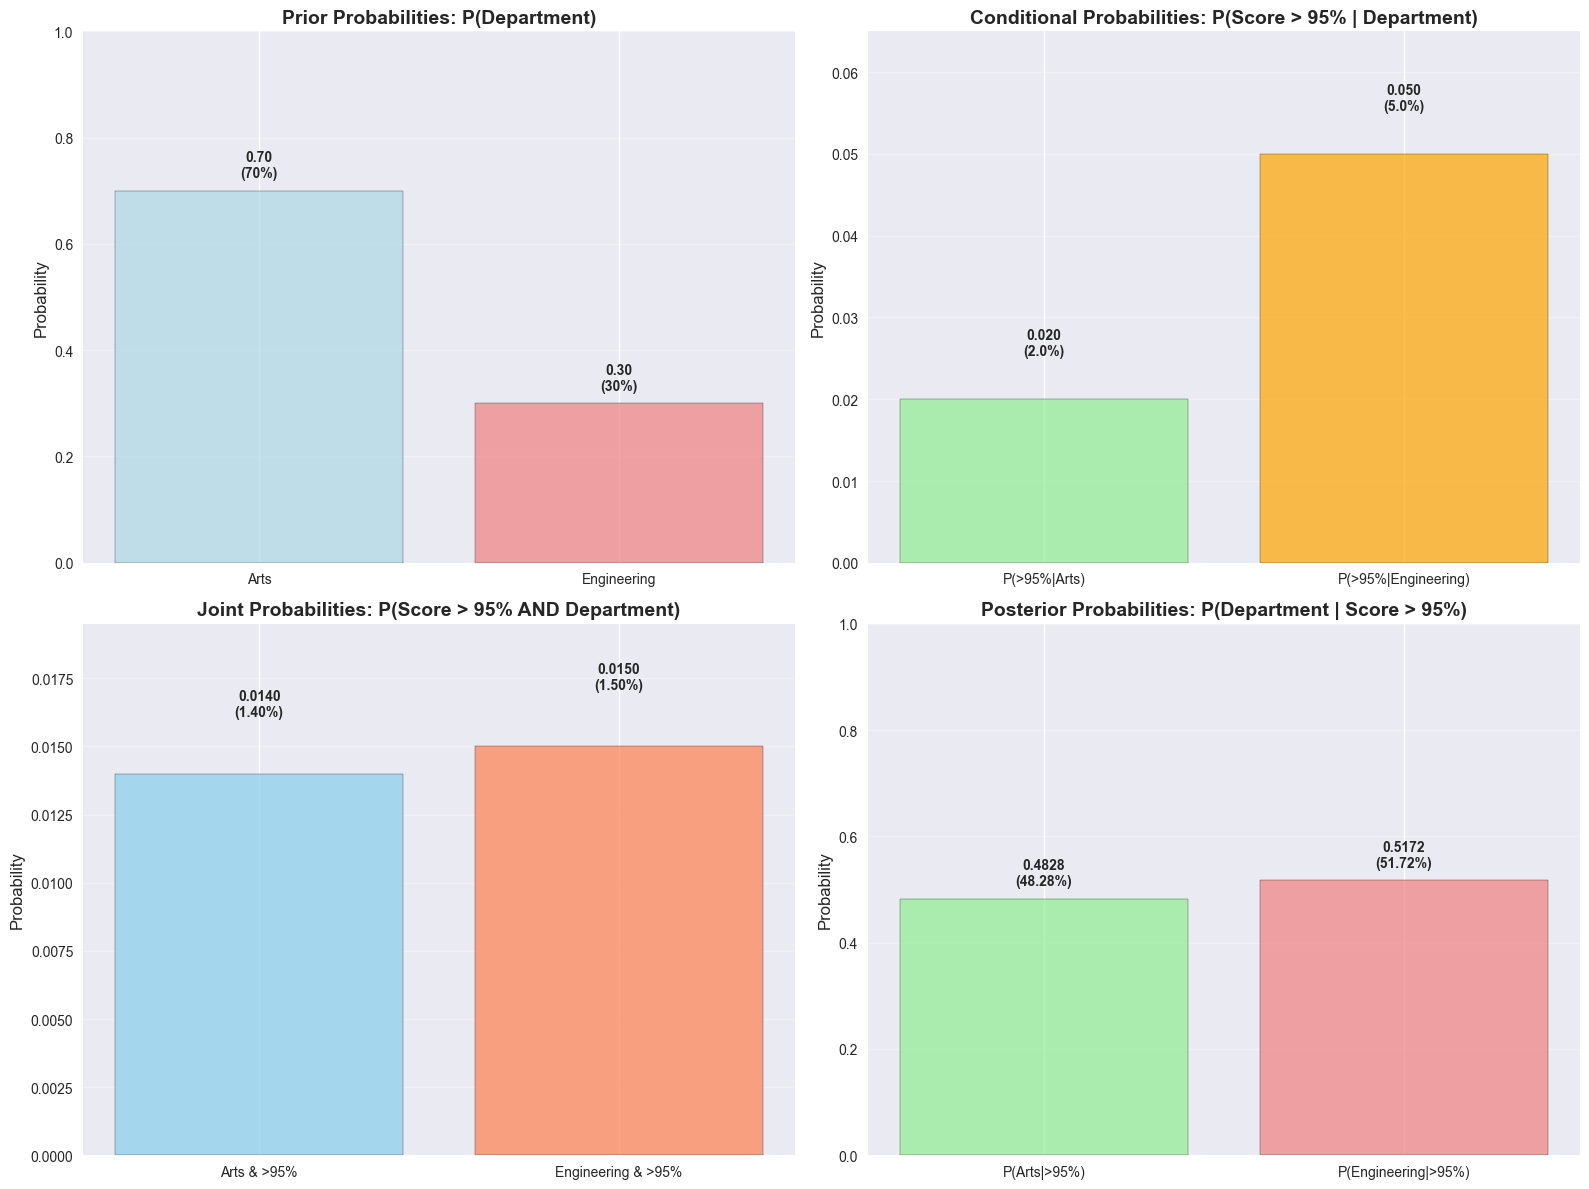

In [6]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Prior probabilities
prior_categories = ['Arts', 'Engineering']
prior_values = [P_arts, P_engineering]
colors_prior = ['lightblue', 'lightcoral']

bars1 = axes[0, 0].bar(prior_categories, prior_values, color=colors_prior, edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Probability', fontsize=12)
axes[0, 0].set_title('Prior Probabilities: P(Department)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, prior_values):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{val:.2f}\n({val*100:.0f}%)', ha='center', va='bottom', fontweight='bold')

# 2. Conditional probabilities
cond_categories = ['P(>95%|Arts)', 'P(>95%|Engineering)']
cond_values = [P_above95_given_arts, P_above95_given_engineering]
colors_cond = ['lightgreen', 'orange']

bars2 = axes[0, 1].bar(cond_categories, cond_values, color=colors_cond, edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('Probability', fontsize=12)
axes[0, 1].set_title('Conditional Probabilities: P(Score > 95% | Department)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylim(0, max(cond_values) * 1.3)
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, cond_values):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{val:.3f}\n({val*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

# 3. Joint probabilities
joint_categories = ['Arts & >95%', 'Engineering & >95%']
joint_values = [P_above95_given_arts * P_arts, P_above95_given_engineering * P_engineering]
colors_joint = ['skyblue', 'coral']

bars3 = axes[1, 0].bar(joint_categories, joint_values, color=colors_joint, edgecolor='black', alpha=0.7)
axes[1, 0].set_ylabel('Probability', fontsize=12)
axes[1, 0].set_title('Joint Probabilities: P(Score > 95% AND Department)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylim(0, max(joint_values) * 1.3)
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, joint_values):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.002,
                    f'{val:.4f}\n({val*100:.2f}%)', ha='center', va='bottom', fontweight='bold')

# 4. Posterior probabilities
posterior_categories = ['P(Arts|>95%)', 'P(Engineering|>95%)']
posterior_values = [P_arts_given_above95, P_engineering_given_above95]
colors_posterior = ['lightgreen', 'lightcoral']

bars4 = axes[1, 1].bar(posterior_categories, posterior_values, color=colors_posterior, edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Probability', fontsize=12)
axes[1, 1].set_title('Posterior Probabilities: P(Department | Score > 95%)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, posterior_values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{val:.4f}\n({val*100:.2f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [7]:
# Summary table
summary_data = {
    'Probability': [
        'P(Arts)',
        'P(Engineering)',
        'P(Score > 95% | Arts)',
        'P(Score > 95% | Engineering)',
        'P(Score > 95%)',
        'P(Arts | Score > 95%)',
        'P(Engineering | Score > 95%)'
    ],
    'Value': [
        f'{P_arts:.4f}',
        f'{P_engineering:.4f}',
        f'{P_above95_given_arts:.4f}',
        f'{P_above95_given_engineering:.4f}',
        f'{P_above95:.4f}',
        f'{P_arts_given_above95:.6f}',
        f'{P_engineering_given_above95:.6f}'
    ],
    'Percentage': [
        f'{P_arts*100:.2f}%',
        f'{P_engineering*100:.2f}%',
        f'{P_above95_given_arts*100:.2f}%',
        f'{P_above95_given_engineering*100:.2f}%',
        f'{P_above95*100:.2f}%',
        f'{P_arts_given_above95*100:.4f}%',
        f'{P_engineering_given_above95*100:.4f}%'
    ]
}
summary_df = pd.DataFrame(summary_data)
print("\nSUMMARY TABLE:")
print(summary_df.to_string(index=False))



SUMMARY TABLE:
                 Probability    Value Percentage
                     P(Arts)   0.7000     70.00%
              P(Engineering)   0.3000     30.00%
       P(Score > 95% | Arts)   0.0200      2.00%
P(Score > 95% | Engineering)   0.0500      5.00%
              P(Score > 95%)   0.0290      2.90%
       P(Arts | Score > 95%) 0.482759   48.2759%
P(Engineering | Score > 95%) 0.517241   51.7241%


## Interpretation

The result shows that even though:
- Only 2% of arts students score above 95% (compared to 5% of engineering students)
- 70% of all students are in arts

When we condition on a student scoring above 95%, the probability that they are an arts student is still quite high. This is because:
1. The large proportion of arts students (70%) means there are many more arts students overall
2. Even with a lower percentage, the absolute number of arts students scoring above 95% can be significant
3. Bayes' theorem properly accounts for both the prior probability and the conditional probability
